# UK Road Casualty Statistics 2025 — Complete Machine Learning Pipeline
### COM 763 Advanced Machine Learning




## 1. Environment Setup & Imports <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, json, os, warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
COLORS = {'Fatal':'#dc2626', 'Serious':'#d97706', 'Slight':'#2563eb'}


In [2]:
cas = pd.read_csv("dft-road-casualty-statistics-casualty-provisional-2025.csv",  low_memory=False)
col = pd.read_csv("dft-road-casualty-statistics-collision-provisional-2025.csv", low_memory=False)
veh = pd.read_csv("dft-road-casualty-statistics-vehicle-provisional-2025.csv",   low_memory=False)


print(f"{'Dataset':<12} {'Rows':>8} {'Columns':>9}")

for name, df in [('Collision', col), ('Casualty', cas), ('Vehicle', veh)]:
    print(f"{name:<12} {df.shape[0]:>8,} {df.shape[1]:>9}")



Dataset          Rows   Columns
Collision      48,472        44
Casualty       60,991        23
Vehicle        87,805        32


In [3]:

print("COLLISION dataset")
col.head()


COLLISION dataset


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2025010551784,2025,010551784,528234.0,185607.0,-0.15174,51.55478,1,3,3,...,0,0,1,1,-1,E01000886,-1,0,0.0,1.0
1,2025010551786,2025,010551786,529585.0,178570.0,-0.13485,51.49124,1,3,2,...,0,0,1,3,-1,E01004747,-1,0,0.0,1.0
2,2025010551792,2025,010551792,524767.0,187961.0,-0.20089,51.57671,1,3,5,...,0,0,1,1,-1,E01000216,-1,0,0.0,1.0
3,2025010551794,2025,010551794,527549.0,184185.0,-0.16213,51.54216,1,2,1,...,2,17,1,1,-1,E01000967,-1,0,1.0,0.0
4,2025010551795,2025,010551795,534910.0,183108.0,-0.05647,51.53077,1,2,2,...,0,0,1,1,-1,E01004198,-1,0,1.0,0.0


In [4]:

print("CASUALTY dataset:")
cas.head()


CASUALTY dataset:


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2025010551784,2025,010551784,3,1,1,1,55,8,3,...,0,0,9,4,E01002814,-1,0,0.0,1.0,2
1,2025010551786,2025,010551786,1,1,1,1,30,6,3,...,0,0,3,3,E01004669,-1,0,0.0,1.0,1
2,2025010551792,2025,010551792,1,1,1,1,29,6,3,...,0,0,9,2,E01002096,-1,0,0.0,1.0,2
3,2025010551794,2025,010551794,1,1,3,1,59,9,2,...,0,0,0,2,E01002852,-1,0,1.0,0.0,1
4,2025010551794,2025,010551794,1,2,3,1,-1,-1,3,...,0,0,0,-1,-1,-1,0,0.0,1.0,-1


In [5]:

print("VEHICLE dataset:")
veh.head()


VEHICLE dataset:


,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2025010551784,2025,010551784,3,9,0,18,19,7,3,...,55,8,-1,-1,-1,-1,4,E01002814,0,2
1,2025010551784,2025,010551784,2,9,0,18,19,3,7,...,36,7,-1,-1,-1,-1,6,E01000892,0,1
2,2025010551784,2025,010551784,1,9,0,18,19,7,3,...,53,8,-1,-1,-1,-1,-1,-1,0,-1
3,2025010551786,2025,010551786,1,3,0,-1,-1,9,9,...,30,6,-1,-1,-1,-1,3,E01004669,0,1
4,2025010551786,2025,010551786,2,9,0,6,6,9,9,...,49,8,-1,-1,-1,-1,5,E01015718,0,4


In [6]:

col.describe().round(2)


,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,...,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
count,48472.0,48471.00,48471.00,48471.00,48471.00,48472.00,48472.00,48472.00,48472.00,48472.00,...,48472.00,48472.00,48472.00,48472.00,48472.00,48472.0,48472.00,48472.00,48472.00,48472.00
mean,2025.0,456275.21,275578.67,-1.19,52.37,27.49,2.72,1.81,1.26,4.14,...,-0.37,-0.39,3.68,1.33,1.50,-1.0,2.16,0.65,0.26,0.73
std,0.0,92138.41,143306.86,1.35,1.29,23.78,0.48,0.69,0.93,1.93,...,1.74,1.68,17.34,0.47,0.88,0.0,2.68,0.48,0.43,0.43
min,2025.0,75011.00,10291.00,-7.44,49.91,1.00,1.00,1.00,1.00,1.00,...,-1.00,-1.00,-1.00,1.00,-1.00,-1.0,-1.00,0.00,0.00,0.00
25%,2025.0,395146.50,175750.50,-2.07,51.47,5.00,2.00,1.00,1.00,3.00,...,-1.00,-1.00,0.00,1.00,1.00,-1.0,-1.00,0.00,0.00,0.00
50%,2025.0,460820.00,222832.00,-1.10,51.89,22.00,3.00,2.00,1.00,4.00,...,-1.00,-1.00,0.00,1.00,1.00,-1.0,3.00,1.00,0.00,1.00
75%,2025.0,529811.50,381414.00,-0.13,53.33,44.00,3.00,2.00,1.00,6.00,...,0.00,0.00,0.00,2.00,2.00,-1.0,3.00,1.00,0.27,1.00
max,2025.0,655126.00,1144900.00,1.76,60.19,99.00,3.00,17.00,142.00,7.00,...,9.00,9.00,99.00,3.00,3.00,-1.0,7.00,1.00,1.00,1.00


In [7]:

cas.describe().round(2)


,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
count,60991.0,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00,60991.00
mean,2025.0,1.42,1.48,1.50,1.36,37.71,6.40,2.76,0.89,0.71,0.22,0.05,-0.09,8.24,4.35,2.16,0.66,0.23,0.76,1.57
std,0.0,1.31,4.00,0.75,0.55,20.30,2.52,0.45,2.32,2.10,0.59,0.45,0.31,13.92,3.24,2.57,0.47,0.41,0.41,1.46
min,2025.0,1.00,1.00,-1.00,-1.00,-1.00,-1.00,1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,0.00,0.00,0.00,-1.00
25%,2025.0,1.00,1.00,1.00,1.00,22.00,5.00,3.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,-1.00,0.00,0.00,0.84,1.00
50%,2025.0,1.00,1.00,1.00,1.00,35.00,6.00,3.00,0.00,0.00,0.00,0.00,0.00,9.00,4.00,3.00,1.00,0.00,1.00,1.00
75%,2025.0,2.00,1.00,2.00,2.00,52.00,8.00,3.00,0.00,0.00,0.00,0.00,0.00,9.00,7.00,3.00,1.00,0.12,1.00,2.00
max,2025.0,291.00,142.00,3.00,9.00,120.00,11.00,3.00,10.00,9.00,9.00,9.00,2.00,99.00,10.00,7.00,1.00,1.00,1.00,5.00


In [8]:
# Data types

print(col.dtypes.to_string())


collision_index                                      object
collision_year                                        int64
collision_ref_no                                     object
location_easting_osgr                               float64
location_northing_osgr                              float64
longitude                                           float64
latitude                                            float64
police_force                                          int64
collision_severity                                    int64
number_of_vehicles                                    int64
number_of_casualties                                  int64
date                                                 object
day_of_week                                           int64
time                                                 object
local_authority_district                              int64
local_authority_ons_district                         object
local_authority_highway                 

## 3. Exploratory Data Analysis (EDA) <a id='3'></a>




In [9]:
#Lookup dictionaries
SEVERITY_MAP   = {1:'Fatal', 2:'Serious', 3:'Slight', -1:'Unknown'}
WEATHER_MAP    = {1:'Fine/no wind', 2:'Raining/no wind', 3:'Snowing/no wind',
                  4:'Fine+wind', 5:'Raining+wind', 6:'Snowing+wind',
                  7:'Fog/mist', 8:'Other', 9:'Unknown', -1:'Unknown'}
ROAD_SURF_MAP  = {1:'Dry', 2:'Wet/damp', 3:'Snow', 4:'Frost/ice', 5:'Flood',
                  9:'Unknown', -1:'Unknown'}
LIGHT_MAP      = {1:'Daylight', 4:'Dark-lit', 5:'Dark-unlit',
                  6:'Dark-no lighting', 7:'Dark-unknown', -1:'Unknown'}
URBAN_MAP      = {1:'Urban', 2:'Rural', 3:'Unallocated'}
DOW_MAP        = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
ROAD_CLASS_MAP = {1:'Motorway', 2:'A(M)', 3:'A road', 4:'B road',
                  5:'C road', 6:'Unclassified'}
JUNCTION_MAP   = {0:'Not junction', 1:'Roundabout', 2:'Mini-roundabout',
                  3:'T/staggered', 5:'Slip road', 6:'Crossroads',
                  7:'4+ arms', 8:'Private drive', 9:'Other', -1:'Unknown'}

# Apply labels
col['date']           = pd.to_datetime(col['date'], dayfirst=True, errors='coerce')
col['month']          = col['date'].dt.month
col['month_name']     = col['date'].dt.strftime('%b')
col['hour']           = col['time'].str.split(':').str[0].astype(float)
col['severity_label'] = col['collision_severity'].map(SEVERITY_MAP)
col['weather_label']  = col['weather_conditions'].map(WEATHER_MAP).fillna('Unknown')
col['light_label']    = col['light_conditions'].map(LIGHT_MAP).fillna('Unknown')
col['road_surf']      = col['road_surface_conditions'].map(ROAD_SURF_MAP).fillna('Unknown')
col['urban_label']    = col['urban_or_rural_area'].map(URBAN_MAP).fillna('Unknown')
col['dow_label']      = col['day_of_week'].map(DOW_MAP).fillna('Unknown')
col['road_class']     = col['first_road_class'].map(ROAD_CLASS_MAP).fillna('Unknown')
col['junction_label'] = col['junction_detail'].map(JUNCTION_MAP).fillna('Unknown')

cas['severity_label'] = cas['casualty_severity'].map(SEVERITY_MAP)
cas['sex_label']      = cas['sex_of_casualty'].map({1:'Male', 2:'Female',
                                                     3:'Unknown', -1:'Unknown'})
cas['class_label']    = cas['casualty_class'].map({1:'Driver/Rider',
                                                    2:'Passenger',
                                                    3:'Pedestrian', -1:'Unknown'})


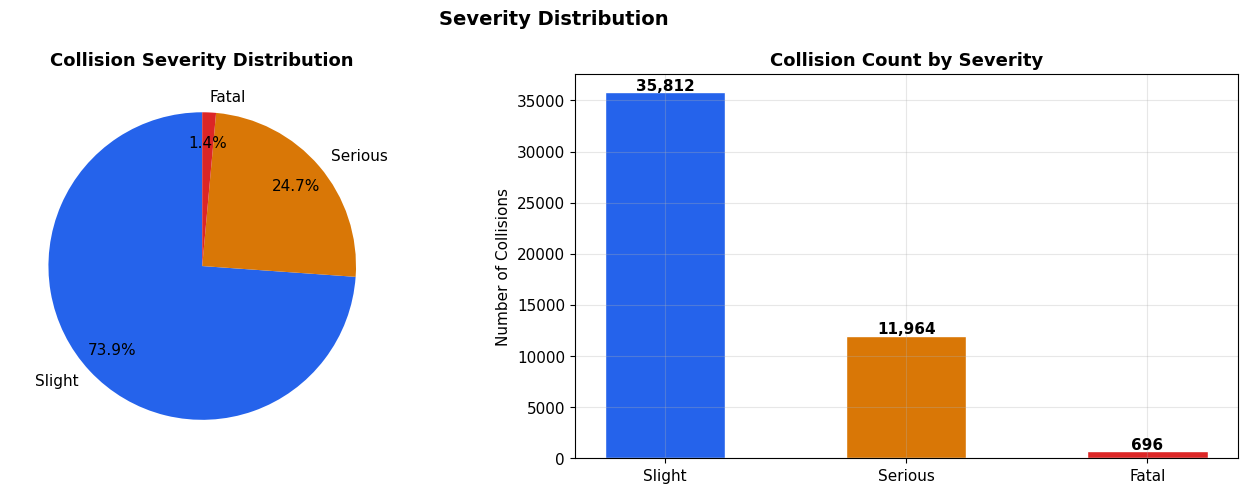

severity_label
Slight     35812
Serious    11964
Fatal        696


In [10]:
# ── Figure 1: Severity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sev_counts = col['severity_label'].value_counts()
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    sev_counts.values,
    labels=sev_counts.index,
    autopct='%1.1f%%',
    colors=[COLORS.get(s,'grey') for s in sev_counts.index],
    startangle=90, pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title('Collision Severity Distribution')

ax2 = axes[1]
bars = ax2.bar(sev_counts.index, sev_counts.values,
               color=[COLORS.get(s,'grey') for s in sev_counts.index],
               edgecolor='white', width=0.5)
for bar, val in zip(bars, sev_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylabel('Number of Collisions')
ax2.set_title('Collision Count by Severity')

plt.suptitle('Severity Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(sev_counts.to_string())


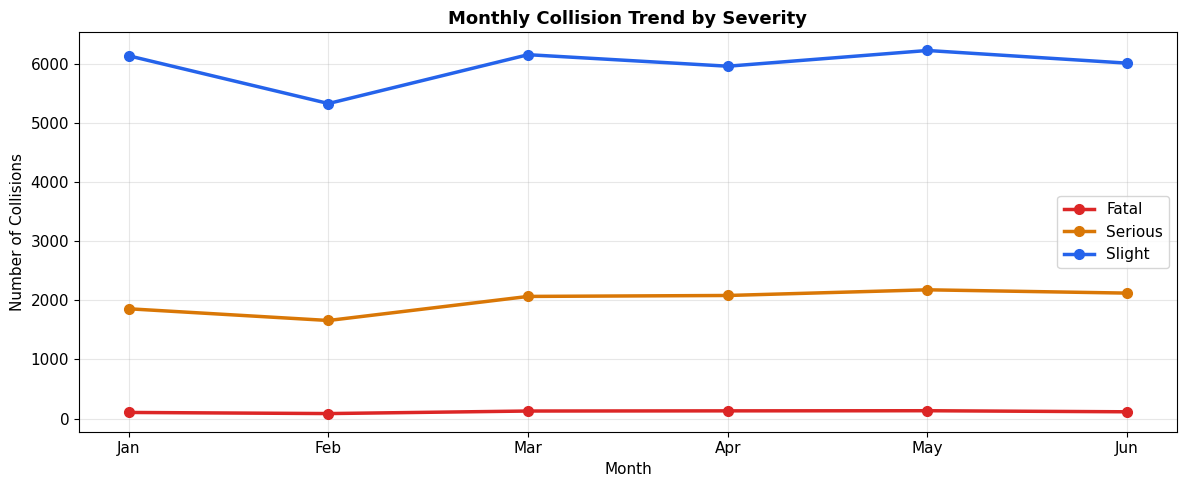

In [11]:
#  Monthly trend by severity

import pandas as pd
import matplotlib.pyplot as plt


col['date'] = pd.to_datetime(col['date'], errors='coerce')


col = col.dropna(subset=['date'])

col['month_name'] = col['date'].dt.strftime('%b')
col['month_num'] = col['date'].dt.month


filtered = col[col['severity_label'].isin(['Fatal', 'Serious', 'Slight'])]


monthly = filtered.groupby(['month_num', 'month_name', 'severity_label']) \
                  .size().reset_index(name='count')


monthly = monthly.sort_values('month_num')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for sev, grp in monthly.groupby('severity_label'):
    ax.plot(grp['month_name'], grp['count'],
            marker='o',
            color=COLORS.get(sev, 'grey'),
            label=sev,
            linewidth=2.5,
            markersize=7)

ax.set_xlabel('Month')
ax.set_ylabel('Number of Collisions')
ax.set_title('Monthly Collision Trend by Severity')
ax.legend()

plt.tight_layout()
plt.show()

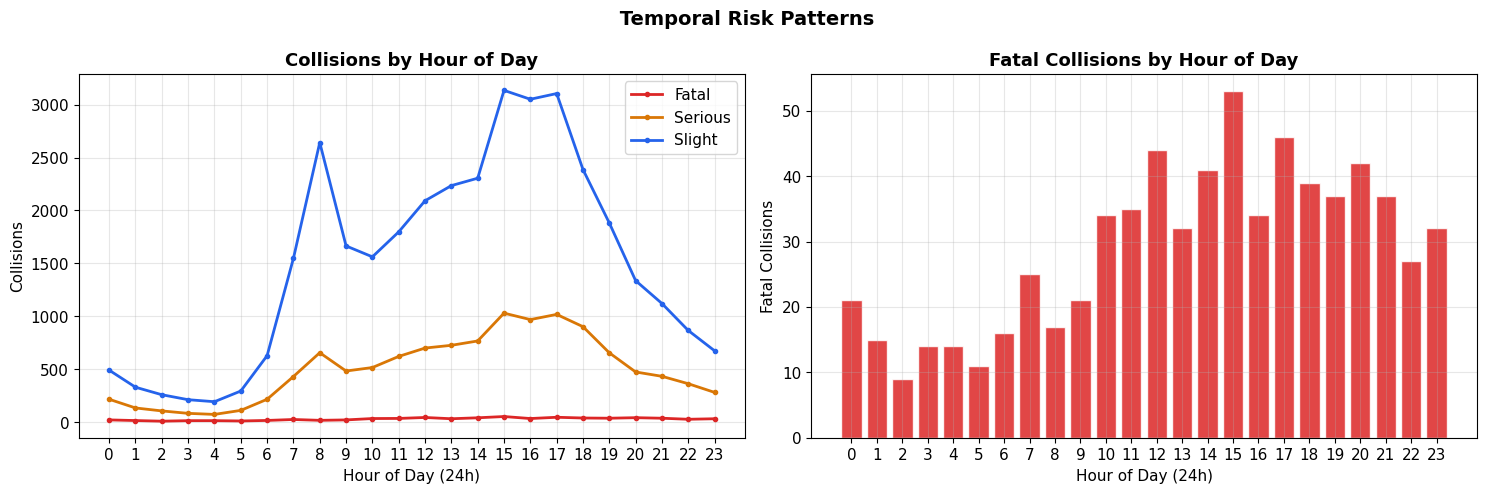

In [12]:
# Hour-of-day pattern
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly = col[col['severity_label'].isin(['Fatal','Serious','Slight'])].groupby(
    ['hour','severity_label']).size().reset_index(name='count')
for sev, grp in hourly.groupby('severity_label'):
    axes[0].plot(grp['hour'], grp['count'], marker='.',
                 color=COLORS.get(sev,'grey'), label=sev, linewidth=2)
axes[0].set_xticks(range(0,24))
axes[0].set_xlabel('Hour of Day (24h)'); axes[0].set_ylabel('Collisions')
axes[0].set_title('Collisions by Hour of Day')
axes[0].legend()

fatal_hour = col[col['collision_severity']==1].groupby('hour').size()
axes[1].bar(fatal_hour.index, fatal_hour.values,
            color='#dc2626', alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(0,24))
axes[1].set_xlabel('Hour of Day (24h)'); axes[1].set_ylabel('Fatal Collisions')
axes[1].set_title('Fatal Collisions by Hour of Day')

plt.suptitle(' Temporal Risk Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


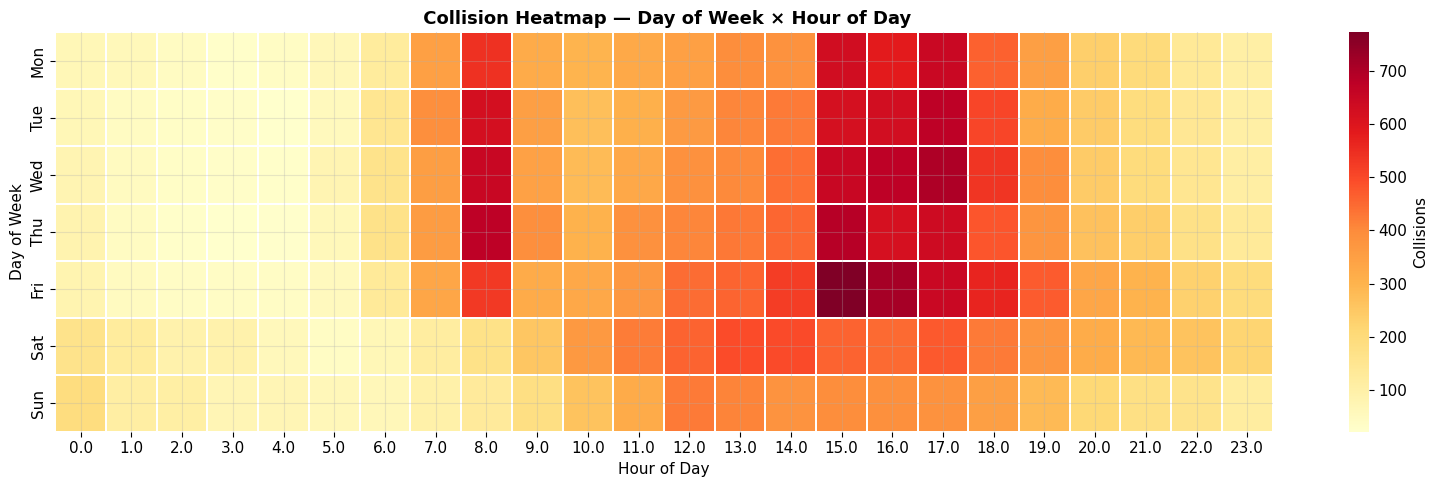

In [13]:
# Day-of-week heatmap
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
col['dow_short'] = col['day_of_week'].map(
    {2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat',1:'Sun'})

hmap = col.groupby(['dow_short','hour']).size().reset_index(name='count')
hmap_piv = hmap.pivot(index='dow_short', columns='hour', values='count').fillna(0)
hmap_piv = hmap_piv.reindex([d for d in dow_order if d in hmap_piv.index])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(hmap_piv, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label':'Collisions'})
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Day of Week')
ax.set_title(' Collision Heatmap — Day of Week × Hour of Day')
plt.tight_layout()
plt.show()


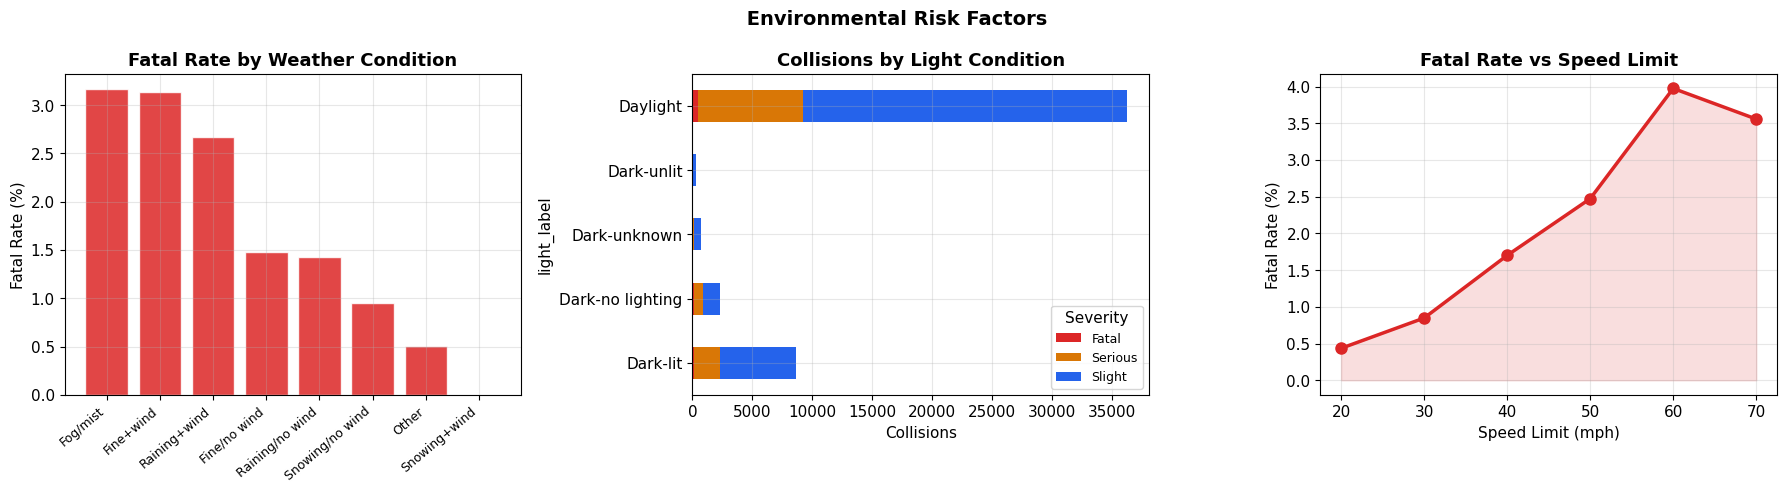

In [14]:
# Weather, Light, Road Surface
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


wx = col[~col['weather_label'].isin(['Unknown'])].groupby('weather_label').agg(
    total=('collision_severity','count'),
    fatal=('collision_severity', lambda x:(x==1).sum())
).reset_index()
wx['fatal_rate'] = wx['fatal']/wx['total']*100
wx = wx.sort_values('fatal_rate', ascending=False)
axes[0].bar(range(len(wx)), wx['fatal_rate'],
            color='#dc2626', alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(wx)))
axes[0].set_xticklabels(wx['weather_label'], rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Fatal Rate (%)')
axes[0].set_title('Fatal Rate by Weather Condition')


lx = col[~col['light_label'].isin(['Unknown'])].groupby(
    ['light_label','severity_label']).size().reset_index(name='count')
light_pivot = lx.pivot(index='light_label', columns='severity_label',
                        values='count').fillna(0)
light_pivot.plot(kind='barh', ax=axes[1], color=[COLORS.get(c,'grey')
                 for c in light_pivot.columns], stacked=True)
axes[1].set_xlabel('Collisions'); axes[1].set_title('Collisions by Light Condition')
axes[1].legend(title='Severity', fontsize=9)


sl_fatal = col[col['speed_limit']>0].groupby('speed_limit').agg(
    total=('collision_severity','count'),
    fatal=('collision_severity', lambda x:(x==1).sum())
).reset_index()
sl_fatal['fatal_rate'] = sl_fatal['fatal']/sl_fatal['total']*100
axes[2].plot(sl_fatal['speed_limit'], sl_fatal['fatal_rate'],
             color='#dc2626', marker='o', linewidth=2.5, markersize=8)
axes[2].fill_between(sl_fatal['speed_limit'], sl_fatal['fatal_rate'],
                     alpha=0.15, color='#dc2626')
axes[2].set_xlabel('Speed Limit (mph)'); axes[2].set_ylabel('Fatal Rate (%)')
axes[2].set_title('Fatal Rate vs Speed Limit')

plt.suptitle(' Environmental Risk Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


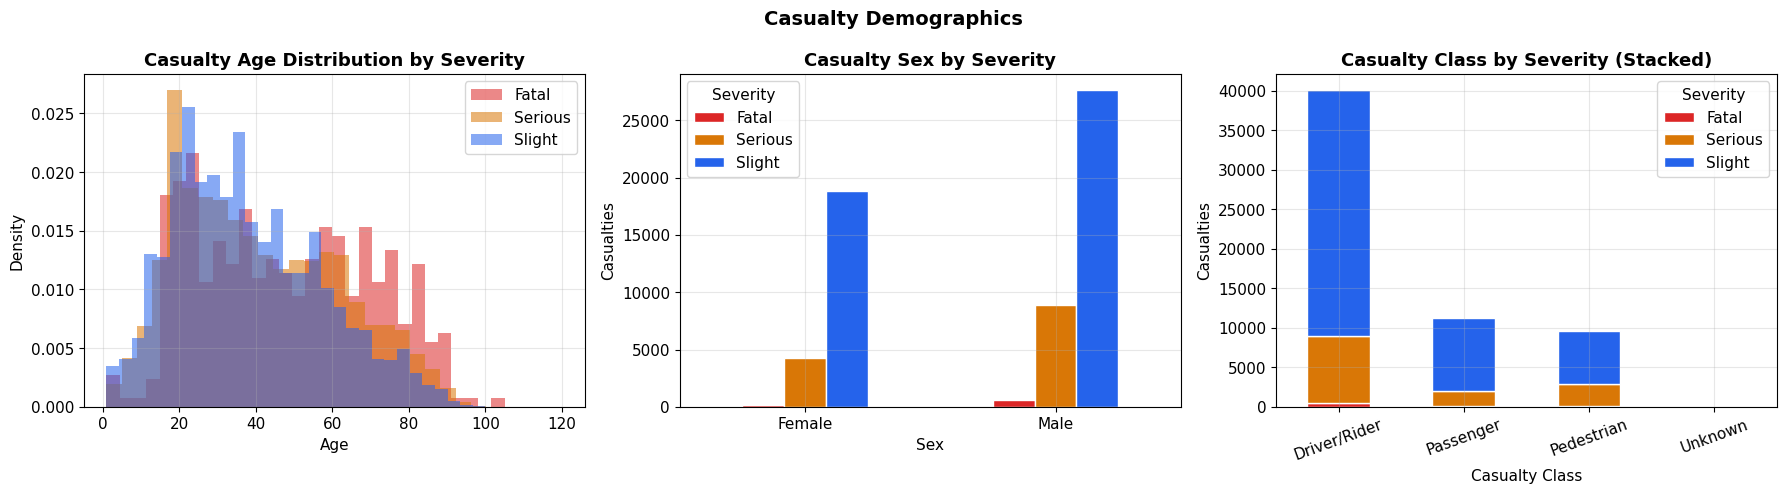

In [15]:
# Casualty demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


valid_age = cas[cas['age_of_casualty'] > 0]
for sev in ['Fatal','Serious','Slight']:
    subset = valid_age[valid_age['severity_label']==sev]
    axes[0].hist(subset['age_of_casualty'], bins=30, alpha=0.55,
                 color=COLORS[sev], label=sev, density=True)
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Density')
axes[0].set_title('Casualty Age Distribution by Severity')
axes[0].legend()


sx = cas[cas['sex_label'].isin(['Male','Female'])].groupby(
    ['sex_label','severity_label']).size().reset_index(name='count')
sx_piv = sx.pivot(index='sex_label', columns='severity_label',
                   values='count').fillna(0)
sx_piv[[c for c in ['Fatal','Serious','Slight'] if c in sx_piv.columns]].plot(
    kind='bar', ax=axes[1],
    color=[COLORS.get(c,'grey') for c in ['Fatal','Serious','Slight']
           if c in sx_piv.columns],
    edgecolor='white', rot=0)
axes[1].set_xlabel('Sex'); axes[1].set_ylabel('Casualties')
axes[1].set_title('Casualty Sex by Severity')
axes[1].legend(title='Severity')

# Casualty class
cls_sev = cas.groupby(['class_label','severity_label']).size().reset_index(name='count')
cls_piv = cls_sev.pivot(index='class_label', columns='severity_label',
                         values='count').fillna(0)
cls_piv[[c for c in ['Fatal','Serious','Slight'] if c in cls_piv.columns]].plot(
    kind='bar', ax=axes[2], stacked=True,
    color=[COLORS.get(c,'grey') for c in ['Fatal','Serious','Slight']
           if c in cls_piv.columns],
    edgecolor='white', rot=20)
axes[2].set_xlabel('Casualty Class'); axes[2].set_ylabel('Casualties')
axes[2].set_title('Casualty Class by Severity (Stacked)')
axes[2].legend(title='Severity')

plt.suptitle('Casualty Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


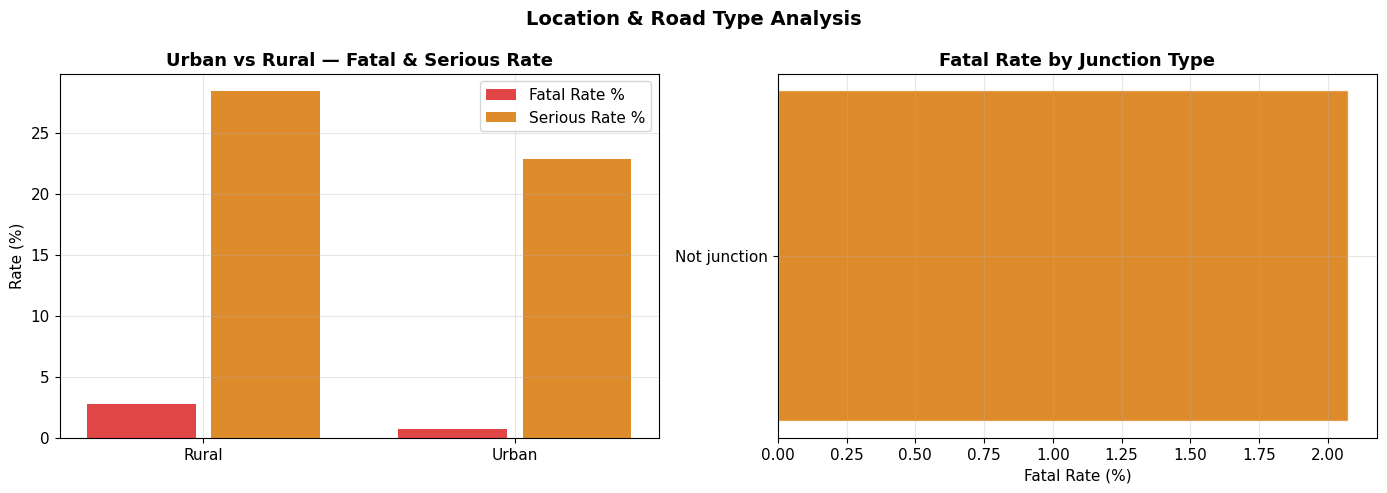

In [16]:
# Urban vs Rural
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Urban vs Rural fatal rate
ur = col[col['urban_label'].isin(['Urban','Rural'])].groupby('urban_label').agg(
    total=('collision_severity','count'),
    fatal=('collision_severity', lambda x:(x==1).sum()),
    serious=('collision_severity', lambda x:(x==2).sum()),
).reset_index()
ur['fatal_rate']   = ur['fatal']/ur['total']*100
ur['serious_rate'] = ur['serious']/ur['total']*100
x = np.arange(len(ur))
axes[0].bar(x-0.2, ur['fatal_rate'],  0.35, label='Fatal Rate %',
            color='#dc2626', alpha=0.85)
axes[0].bar(x+0.2, ur['serious_rate'],0.35, label='Serious Rate %',
            color='#d97706', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(ur['urban_label'])
axes[0].set_ylabel('Rate (%)'); axes[0].set_title('Urban vs Rural — Fatal & Serious Rate')
axes[0].legend()


jct = col[~col['junction_label'].isin(['Unknown'])].groupby('junction_label').agg(
    total=('collision_severity','count'),
    fatal=('collision_severity', lambda x:(x==1).sum())
).reset_index()
jct['fatal_rate'] = jct['fatal']/jct['total']*100
jct = jct.sort_values('fatal_rate', ascending=True)
axes[1].barh(jct['junction_label'], jct['fatal_rate'],
             color='#d97706', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Fatal Rate (%)'); axes[1].set_title('Fatal Rate by Junction Type')

plt.suptitle('Location & Road Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


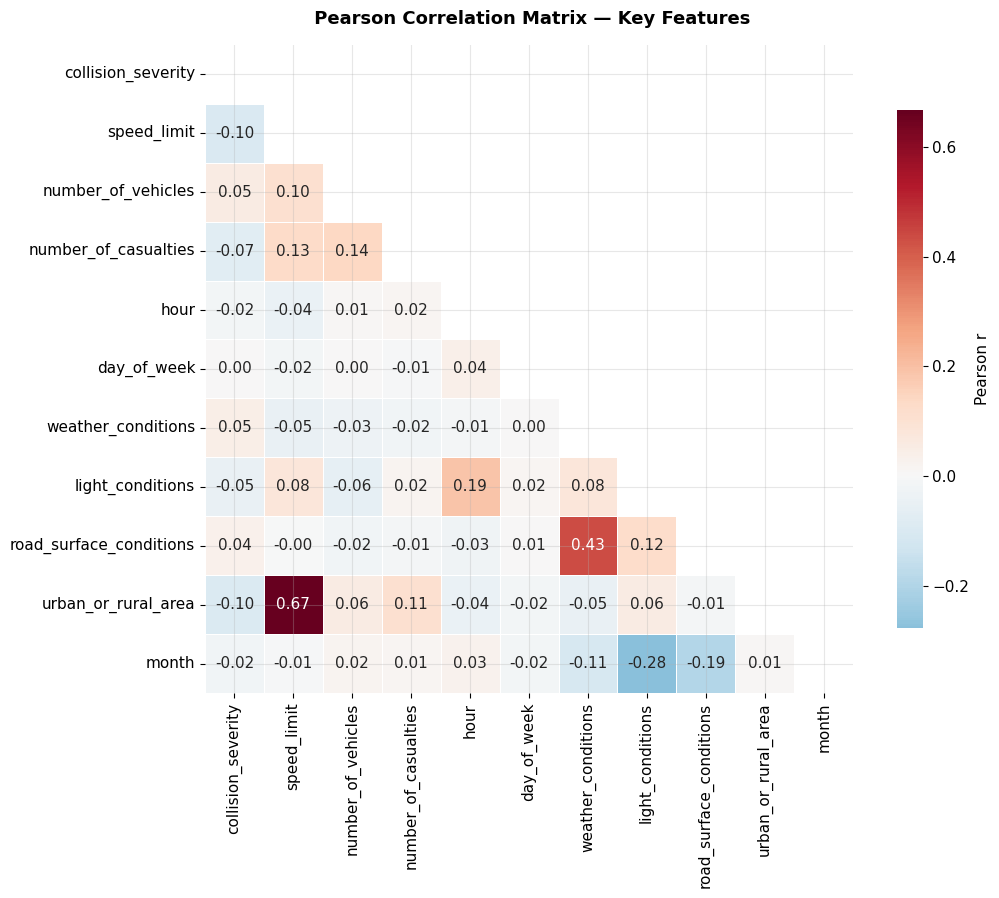

In [17]:
#  Correlation matrix
corr_cols = ['collision_severity','speed_limit','number_of_vehicles',
             'number_of_casualties','hour','day_of_week',
             'weather_conditions','light_conditions',
             'road_surface_conditions','urban_or_rural_area','month']
corr_df = col[corr_cols].replace(-1, np.nan).dropna()
corr    = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink':0.8, 'label':'Pearson r'})
ax.set_title(' Pearson Correlation Matrix — Key Features', pad=15)
plt.tight_layout()

plt.show()


## 4. Missing Value & Sentinel Analysis <a id='4'></a>



In [18]:
# NaN check
any_found = False
for name, df in [('Collision',col),('Casualty',cas),('Vehicle',veh)]:
    ns = df.isnull().sum()
    ns = ns[ns > 0]
    if len(ns):
        any_found = True
        print(f"\n{name}:")
        for c,n in ns.items():
            print(f"  {c}: {n} ({n/len(df)*100:.2f}%)")
if not any_found:
    print("  No NaN values in any dataset.")



Collision:
  location_easting_osgr: 1 (0.00%)
  location_northing_osgr: 1 (0.00%)
  longitude: 1 (0.00%)
  latitude: 1 (0.00%)
  local_authority_highway_current: 3 (0.01%)

Casualty:
  sex_label: 18 (0.03%)


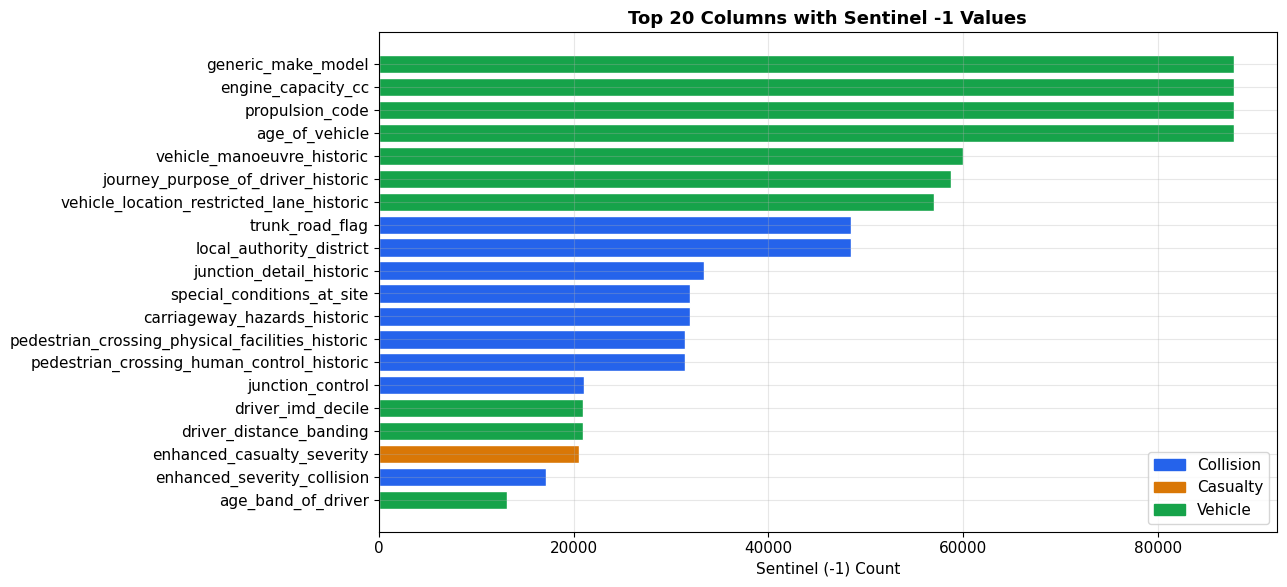


Total columns with sentinel -1: 59
  Dataset                                           Column  Count        Pct
  Vehicle                               generic_make_model  87805 100.000000
  Vehicle                               engine_capacity_cc  87805 100.000000
  Vehicle                                  propulsion_code  87805 100.000000
  Vehicle                                   age_of_vehicle  87805 100.000000
  Vehicle                       vehicle_manoeuvre_historic  59944  68.269461
  Vehicle               journey_purpose_of_driver_historic  58708  66.861796
  Vehicle        vehicle_location_restricted_lane_historic  56975  64.888104
Collision                                  trunk_road_flag  48472 100.000000
Collision                         local_authority_district  48472 100.000000
Collision                         junction_detail_historic  33434  68.975904
Collision                       special_conditions_at_site  31898  65.807064
Collision                     carriagewa

In [19]:

fig, ax = plt.subplots(figsize=(13, 6))

sent_data = []
for ds_name, df in [('Collision',col),('Casualty',cas),('Vehicle',veh)]:
    for c in df.select_dtypes(include='number').columns:
        n = (df[c]==-1).sum()
        if n > 0:
            sent_data.append({'Dataset':ds_name,'Column':c,'Count':n,
                              'Pct':n/len(df)*100})
sent_df = pd.DataFrame(sent_data).sort_values('Count',ascending=False).head(20)
palette = {'Collision':'#2563eb','Casualty':'#d97706','Vehicle':'#16a34a'}
bar_colors = [palette[d] for d in sent_df['Dataset']]
bars = ax.barh(sent_df['Column'], sent_df['Count'],
               color=bar_colors, edgecolor='white')
ax.set_xlabel('Sentinel (-1) Count')
ax.set_title('Top 20 Columns with Sentinel -1 Values')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v,label=k) for k,v in palette.items()])
plt.tight_layout()
plt.show()

print(f"\nTotal columns with sentinel -1: {len(sent_data)}")
print(pd.DataFrame(sent_data).sort_values('Count',ascending=False).to_string(index=False))


## 5. Duplicate Check <a id='5'></a>

In [20]:

for name, df in [('Collision',col),('Casualty',cas),('Vehicle',veh)]:
    dupes = df.duplicated().sum()
    print(f"  {name:<12}: {dupes:>4} duplicates")


  Collision   :    0 duplicates
  Casualty    :    0 duplicates
  Vehicle     :    0 duplicates


## 6. Feature Engineering <a id='6'></a>

New features derived from raw columns to expose temporal patterns and


In [21]:

bins       = [0,17,25,35,45,55,65,120]
band_labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
cas['age_band'] = pd.cut(cas['age_of_casualty'].replace(-1,np.nan),
                          bins=bins, labels=band_labels)


print(f"{'Feature':<22} {'Source':<28} {'Type'}")

fe_list = [
    ('hour',           'time (HH:MM split)',       'Numeric'),
    ('month',          'date',                     'Numeric'),
    ('month_name',     'date',                     'Categorical'),
    ('severity_label', 'collision_severity',       'Categorical'),
    ('weather_label',  'weather_conditions',       'Categorical'),
    ('light_label',    'light_conditions',         'Categorical'),
    ('road_surf',      'road_surface_conditions',  'Categorical'),
    ('urban_label',    'urban_or_rural_area',      'Categorical'),
    ('dow_label',      'day_of_week',              'Categorical'),
    ('road_class',     'first_road_class',         'Categorical'),
    ('junction_label', 'junction_detail',          'Categorical'),
    ('age_band',       'age_of_casualty',          'Ordinal '),
    ('target',         'collision_severity',       'Binary ML target'),
]
for f,s,t in fe_list:
    print(f"  {f:<22} {s:<28} {t}")


Feature                Source                       Type
  hour                   time (HH:MM split)           Numeric
  month                  date                         Numeric
  month_name             date                         Categorical
  severity_label         collision_severity           Categorical
  weather_label          weather_conditions           Categorical
  light_label            light_conditions             Categorical
  road_surf              road_surface_conditions      Categorical
  urban_label            urban_or_rural_area          Categorical
  dow_label              day_of_week                  Categorical
  road_class             first_road_class             Categorical
  junction_label         junction_detail              Categorical
  age_band               age_of_casualty              Ordinal 
  target                 collision_severity           Binary ML target


In [22]:
FEAT_COLS = [
    'speed_limit', 'number_of_vehicles', 'number_of_casualties',
    'hour', 'day_of_week', 'weather_conditions', 'light_conditions',
    'road_surface_conditions', 'urban_or_rural_area', 'month',
    'junction_detail', 'first_road_class', 'pedestrian_crossing'
]


ml_df = col[FEAT_COLS + ['collision_severity']].copy()
ml_df = ml_df[ml_df['collision_severity'].isin([1,2,3])]
ml_df = ml_df[ml_df['speed_limit'] > 0]
for c in FEAT_COLS:
    ml_df = ml_df[ml_df[c] != -1]
ml_df.dropna(inplace=True)
ml_df['target'] = (ml_df['collision_severity'].isin([1,2])).astype(int)


print(f"Total rows: {len(ml_df):,}")
print(f"Features:   {len(FEAT_COLS)}")
print()
vc = ml_df['target'].value_counts()
for cls, cnt in vc.items():
    lbl = 'Serious/Fatal' if cls==1 else 'Slight'
    print(f"  Class {cls} ({lbl}): {cnt:,}  ({cnt/len(ml_df)*100:.1f}%)")


Total rows: 41,574
Features:   13

  Class 0 (Slight): 30,077  (72.3%)
  Class 1 (Serious/Fatal): 11,497  (27.7%)


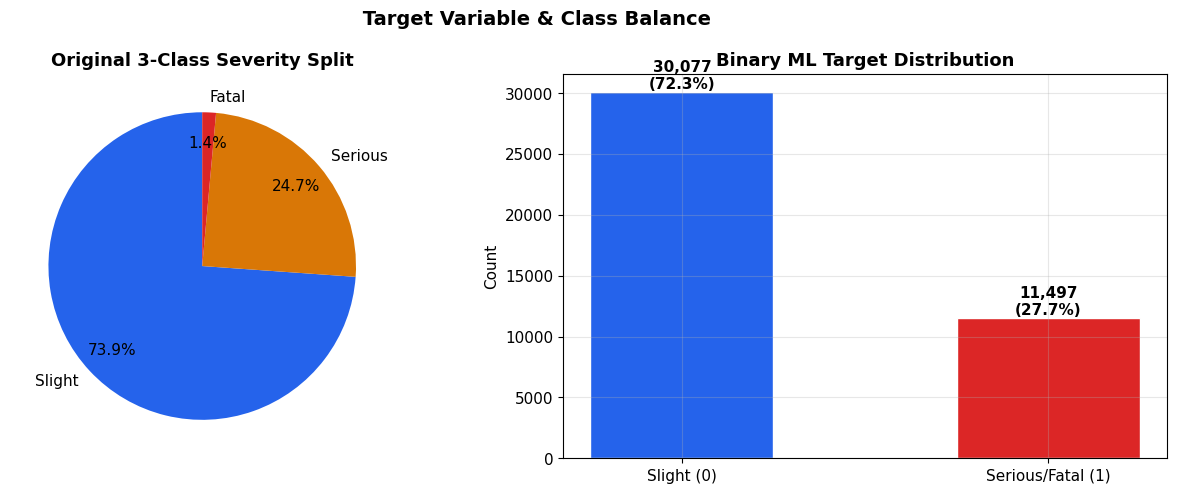

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


orig = col['severity_label'].value_counts()
wedge_colors = [COLORS.get(s,'grey') for s in orig.index]
axes[0].pie(orig.values, labels=orig.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=90, pctdistance=0.8)
axes[0].set_title('Original 3-Class Severity Split')


vc = ml_df['target'].value_counts()
labels = ['Slight (0)','Serious/Fatal (1)']
axes[1].bar(labels, [vc.get(0,0), vc.get(1,0)],
            color=['#2563eb','#dc2626'], edgecolor='white', width=0.5)
for i,(lbl,cnt) in enumerate(zip(labels, [vc.get(0,0),vc.get(1,0)])):
    axes[1].text(i, cnt+300, f'{cnt:,}\n({cnt/len(ml_df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].set_title('Binary ML Target Distribution')

plt.suptitle(' Target Variable & Class Balance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Train / Test Split & Scaling <a id='8'></a>

**80/20 stratified split** to preserve class balance in both sets.  
StandardScaler fitted **only on training data** to prevent data leakage.


In [24]:
X = ml_df[FEAT_COLS]
y = ml_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)


print(f"{'Split':<12} {'Rows':>8} {'Pos Class':>12}")

print(f"{'Training':<12} {X_train.shape[0]:>8,} {y_train.mean()*100:>11.1f}%")
print(f"{'Test':<12} {X_test.shape[0]:>8,} {y_test.mean()*100:>11.1f}%")

print(f"\nScaler mean (first 5 features): {scaler.mean_[:5].round(3)}")
print(f"Scaler std  (first 5 features): {scaler.scale_[:5].round(3)}")


Split            Rows    Pos Class
Training       33,259        27.7%
Test            8,315        27.6%

Scaler mean (first 5 features): [36.289  1.809  1.275 13.713  4.139]
Scaler std  (first 5 features): [14.718  0.715  1.041  5.071  1.933]


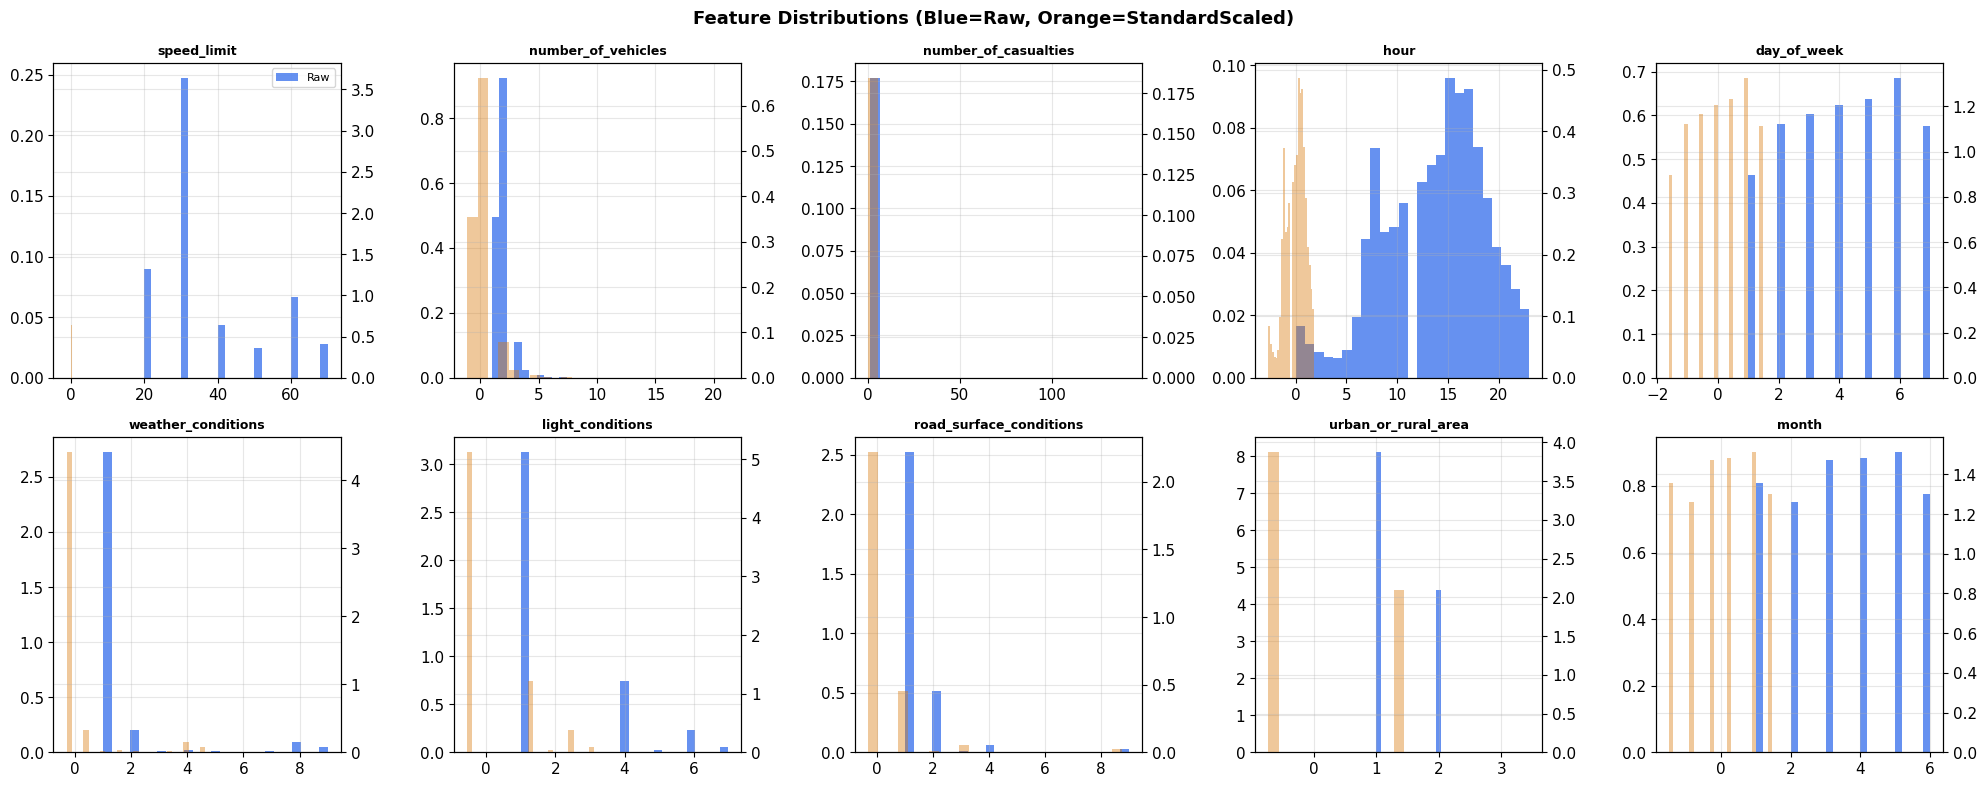

In [25]:
# Figure 11: Feature distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, feat in enumerate(FEAT_COLS[:10]):
    ax = axes[i//5][i%5]
    ax.hist(X_train[feat].values, bins=25, color='#2563eb', alpha=0.7,
            label='Raw', density=True)
    ax2 = ax.twinx()
    ax2.hist(X_train_sc[:, i], bins=25, color='#d97706', alpha=0.4,
             label='Scaled', density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Feature Distributions (Blue=Raw, Orange=StandardScaled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()


## 9. Unsupervised Learning — K-Means Clustering <a id='9'></a>

K-Means clustering is applied to discover **natural groupings** in collision patterns
without using the severity label.  
Elbow method + Silhouette score used to select optimal K.


In [26]:
# ── Elbow method ───────────────────────────────────────────────────
inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_sc, km.labels_,
                                       sample_size=5000, random_state=42))
    print(f"  K={k}: Inertia={km.inertia_:,.0f}  Silhouette={sil_scores[-1]:.4f}")


  K=2: Inertia=377,477  Silhouette=0.1667
  K=3: Inertia=343,836  Silhouette=0.1785
  K=4: Inertia=320,725  Silhouette=0.1633
  K=5: Inertia=304,842  Silhouette=0.1237
  K=6: Inertia=283,159  Silhouette=0.1233
  K=7: Inertia=267,569  Silhouette=0.1345
  K=8: Inertia=258,525  Silhouette=0.1253
  K=9: Inertia=242,429  Silhouette=0.1433
  K=10: Inertia=233,135  Silhouette=0.1071


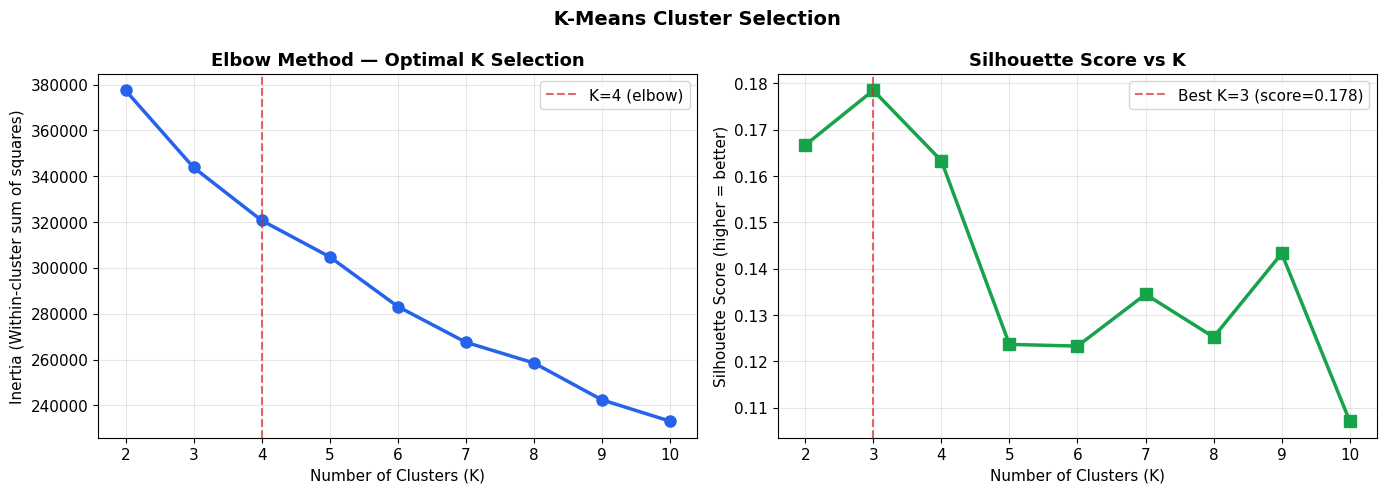


Selected K = 3 (highest silhouette score = 0.1785)


In [27]:
#  Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='#2563eb', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method — Optimal K Selection')
axes[0].axvline(x=4, color='#dc2626', linestyle='--', alpha=0.7, label='K=4 (elbow)')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 's-', color='#16a34a', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_title('Silhouette Score vs K')
best_k = list(K_range)[int(np.argmax(sil_scores))]
axes[1].axvline(x=best_k, color='#dc2626', linestyle='--', alpha=0.7,
                label=f'Best K={best_k} (score={max(sil_scores):.3f})')
axes[1].legend()

plt.suptitle(' K-Means Cluster Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nSelected K = {best_k} (highest silhouette score = {max(sil_scores):.4f})")


In [28]:
# Fit final K-Means
OPTIMAL_K = best_k
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_final.fit(X_train_sc)


X_all_sc = scaler.transform(X)
cluster_labels = kmeans_final.predict(X_all_sc)
ml_df = ml_df.copy()
ml_df['cluster'] = cluster_labels

print(f"K-Means fitted with K={OPTIMAL_K}")
print(f"Silhouette Score: {silhouette_score(X_train_sc, kmeans_final.labels_, sample_size=5000, random_state=42):.4f}")
print()
print("Cluster sizes:")
for k, cnt in sorted(ml_df['cluster'].value_counts().items()):
    print(f"  Cluster {k}: {cnt:,} collisions")


K-Means fitted with K=3
Silhouette Score: 0.1785

Cluster sizes:
  Cluster 0: 25,659 collisions
  Cluster 1: 13,589 collisions
  Cluster 2: 2,326 collisions


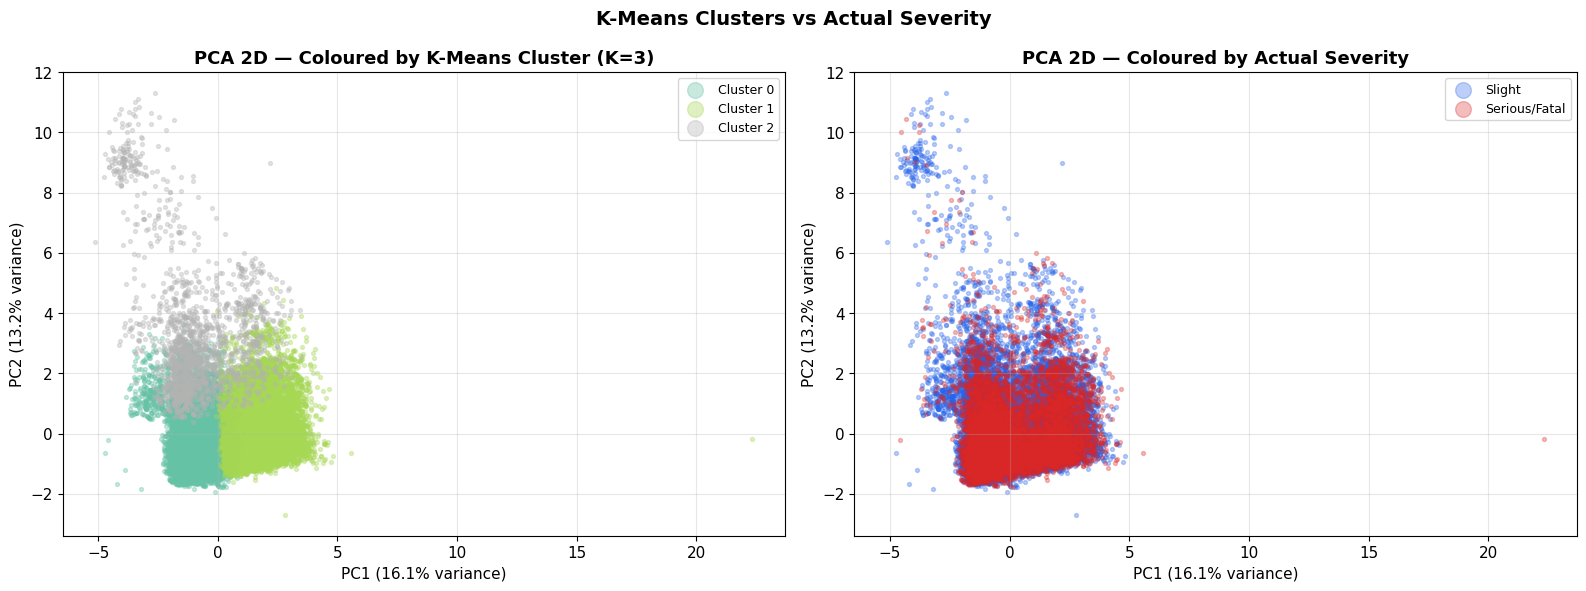

PCA explains 29.2% of total variance in 2 components.


In [29]:
#  PCA 2D cluster visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_sc)
train_clusters = kmeans_final.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


scatter_colors = plt.cm.Set2(np.linspace(0, 1, OPTIMAL_K))
for k in range(OPTIMAL_K):
    mask = train_clusters == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[scatter_colors[k]], label=f'Cluster {k}',
                    alpha=0.35, s=8)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title(f'PCA 2D — Coloured by K-Means Cluster (K={OPTIMAL_K})')
axes[0].legend(markerscale=4, fontsize=9)

# Coloured by actual severity
y_train_arr = y_train.values
for sev_val, sev_lbl, c in [(0,'Slight','#2563eb'),(1,'Serious/Fatal','#dc2626')]:
    mask = y_train_arr == sev_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=c, label=sev_lbl, alpha=0.3, s=8)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('PCA 2D — Coloured by Actual Severity')
axes[1].legend(markerscale=4, fontsize=9)

plt.suptitle('K-Means Clusters vs Actual Severity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance in 2 components.")


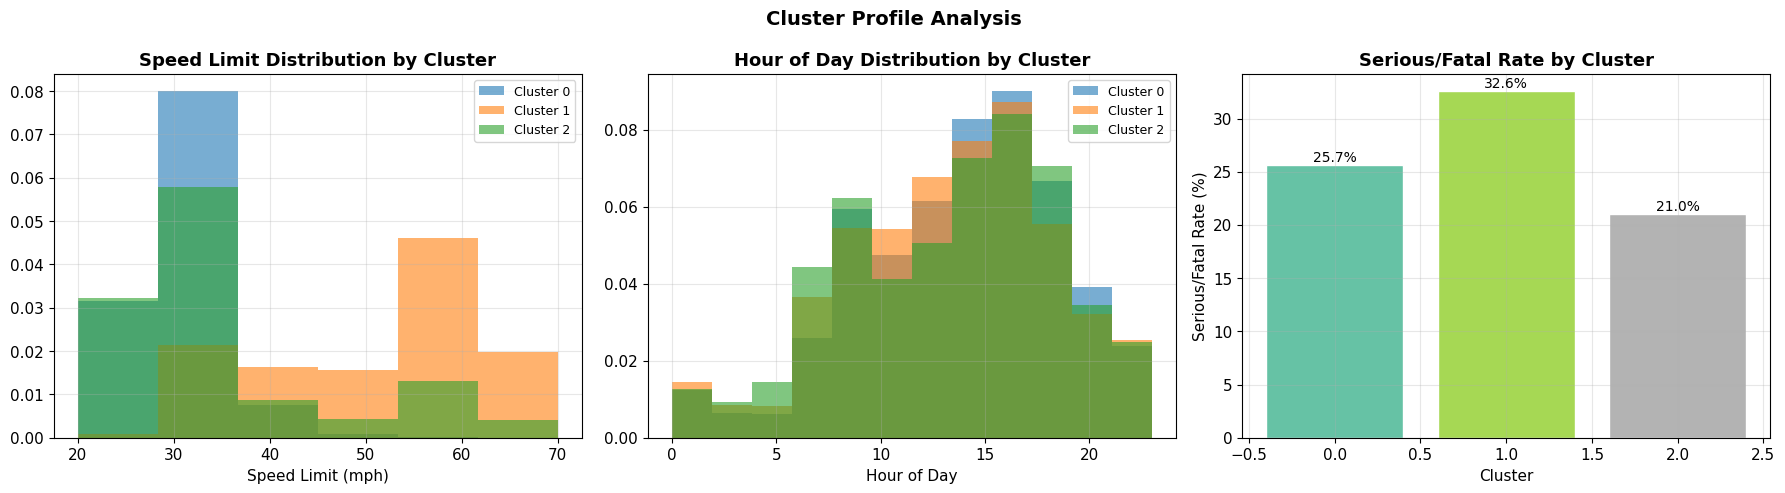


Cluster Summary:
 cluster  serious_fatal_rate  count
       0            0.256518  25659
       1            0.325705  13589
       2            0.210232   2326


In [30]:
# Cluster profile analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cluster — speed limit
for k in range(OPTIMAL_K):
    subset = ml_df[ml_df['cluster']==k]['speed_limit']
    axes[0].hist(subset, bins=6, alpha=0.6, label=f'Cluster {k}', density=True)
axes[0].set_xlabel('Speed Limit (mph)')
axes[0].set_title('Speed Limit Distribution by Cluster')
axes[0].legend(fontsize=9)

# Cluster — hour of day
for k in range(OPTIMAL_K):
    subset = ml_df[ml_df['cluster']==k]['hour']
    axes[1].hist(subset.dropna(), bins=12, alpha=0.6, label=f'Cluster {k}', density=True)
axes[1].set_xlabel('Hour of Day')
axes[1].set_title('Hour of Day Distribution by Cluster')
axes[1].legend(fontsize=9)

# Cluster — severity composition
cluster_sev = ml_df.groupby('cluster')['target'].agg(['mean','count']).reset_index()
cluster_sev.columns = ['cluster','serious_fatal_rate','count']
axes[2].bar(cluster_sev['cluster'], cluster_sev['serious_fatal_rate']*100,
            color=plt.cm.Set2(np.linspace(0,1,OPTIMAL_K)), edgecolor='white')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Serious/Fatal Rate (%)')
axes[2].set_title('Serious/Fatal Rate by Cluster')
for i,(_, row) in enumerate(cluster_sev.iterrows()):
    axes[2].text(i, row['serious_fatal_rate']*100+0.3,
                 f"{row['serious_fatal_rate']*100:.1f}%", ha='center', fontsize=10)

plt.suptitle('Cluster Profile Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

print("\nCluster Summary:")
print(cluster_sev.to_string(index=False))


In [31]:

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=FEAT_COLS
).round(2)
centroids_df.index.name = 'Cluster'
print("K-Means Cluster Centroids")
print(centroids_df.T.to_string())


K-Means Cluster Centroids
Cluster                      0      1      2
speed_limit              28.15  52.13  33.30
number_of_vehicles        1.77   1.91   1.71
number_of_casualties      1.19   1.46   1.17
hour                     13.90  13.42  13.38
day_of_week               4.17   4.08   4.16
weather_conditions        1.08   1.14   7.75
light_conditions          1.79   2.05   2.34
road_surface_conditions   1.17   1.28   2.75
urban_or_rural_area       1.04   1.95   1.27
month                     3.55   3.63   2.76
junction_detail           8.69   4.19   7.72
first_road_class          4.61   3.73   4.29
pedestrian_crossing       5.90   0.58  15.33


In [32]:
NEEDS_SCALING = {'Logistic Regression', 'K-Nearest Neighbours'}

models_def = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
    ),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=11),
}

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Training models")

for name, model in models_def.items():
    Xtr = X_train_sc if name in NEEDS_SCALING else X_train.values
    Xte = X_test_sc  if name in NEEDS_SCALING else X_test.values

    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    cv_sc = cross_val_score(model, Xtr, y_train, cv=cv_splitter, scoring='f1')

    results[name] = {
        'model':         model,
        'y_pred':        y_pred,
        'y_prob':        y_prob,
        'acc':           accuracy_score(y_test, y_pred),
        'precision':     precision_score(y_test, y_pred, average='weighted'),
        'recall':        recall_score(y_test, y_pred, average='weighted'),
        'f1':            f1_score(y_test, y_pred, average='weighted'),
        'f1_macro':      f1_score(y_test, y_pred, average='macro'),
        'auc':           roc_auc_score(y_test, y_prob),
        'cm':            confusion_matrix(y_test, y_pred),
        'cv_mean':       cv_sc.mean(),
        'cv_std':        cv_sc.std(),
        'needs_scaling': name in NEEDS_SCALING,
    }


    print(f"       Acc={results[name]['acc']:.4f}  "
          f"F1(w)={results[name]['f1']:.4f}  "
          f"AUC={results[name]['auc']:.4f}  "
          f"CV-F1={results[name]['cv_mean']:.4f}±{results[name]['cv_std']:.4f}")


best_name = max(results, key=lambda n: results[n]['cv_mean'])

print(f"\n Best Model (CV-based): {best_name} ")
print(f"    CV-F1 = {results[best_name]['cv_mean']:.4f}")
print(f"    F1(w) = {results[best_name]['f1']:.4f}")

Training models
       Acc=0.5722  F1(w)=0.5940  AUC=0.5869  CV-F1=0.4147±0.0047
       Acc=0.6210  F1(w)=0.6367  AUC=0.6148  CV-F1=0.4165±0.0059
       Acc=0.7265  F1(w)=0.6248  AUC=0.6186  CV-F1=0.0641±0.0047
       Acc=0.7086  F1(w)=0.6479  AUC=0.5661  CV-F1=0.1742±0.0097

 Best Model (CV-based): Random Forest 
    CV-F1 = 0.4165
    F1(w) = 0.6367


## 11. Model Evaluation & Comparison <a id='11'></a>

In [33]:

perf = []
for name, r in results.items():
    perf.append({
        'Model':        name,
        'Accuracy':     round(r['acc'],      4),
        'Precision(w)': round(r['precision'],4),
        'Recall(w)':    round(r['recall'],   4),
        'F1(weighted)': round(r['f1'],       4),
        'F1(macro)':    round(r['f1_macro'], 4),
        'AUC-ROC':      round(r['auc'],      4),
        'Best?':        'YES' if name == best_name else ''
    })
perf_df = pd.DataFrame(perf).set_index('Model')
print(perf_df.to_string())


                      Accuracy  Precision(w)  Recall(w)  F1(weighted)  F1(macro)  AUC-ROC Best?
Model                                                                                          
Logistic Regression     0.5722        0.6463     0.5722        0.5940     0.5366   0.5869      
Random Forest           0.6210        0.6654     0.6210        0.6367     0.5716   0.6148   YES
Gradient Boosting       0.7265        0.6929     0.7265        0.6248     0.4509   0.6186      
K-Nearest Neighbours    0.7086        0.6461     0.7086        0.6479     0.5069   0.5661      


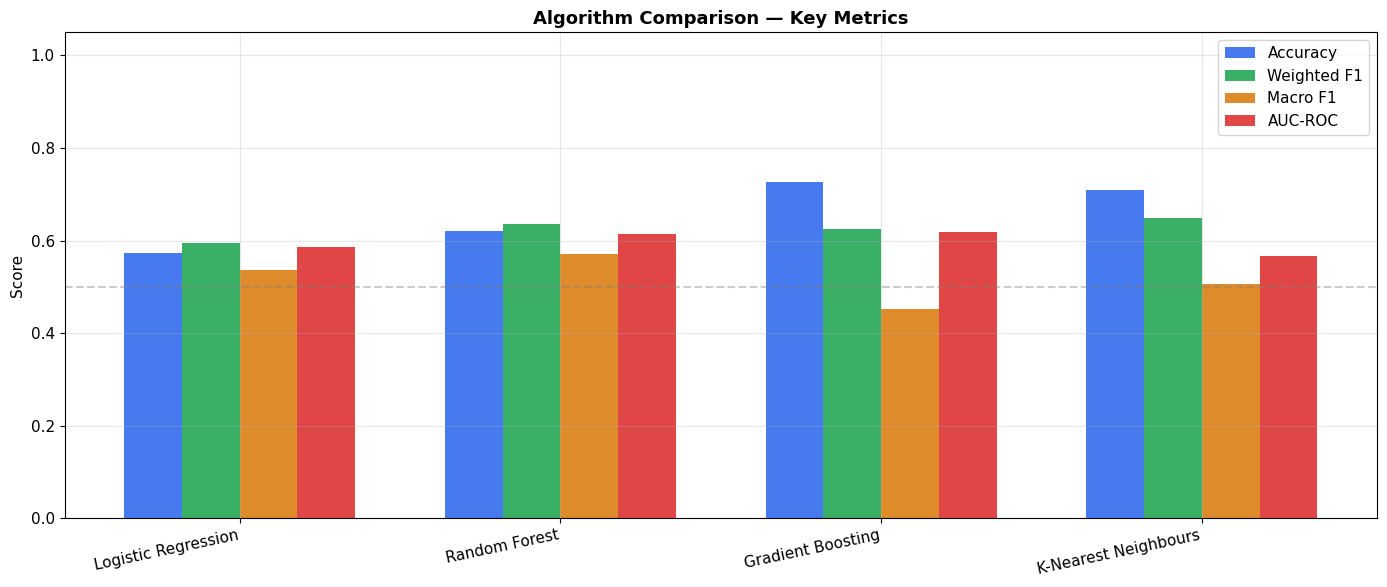

In [34]:
# Performance comparison bar chart
metrics  = ['acc','f1','f1_macro','auc']
m_labels = ['Accuracy','Weighted F1','Macro F1','AUC-ROC']
names    = list(results.keys())
x        = np.arange(len(names))
width    = 0.18
bar_clrs = ['#2563eb','#16a34a','#d97706','#dc2626']

fig, ax = plt.subplots(figsize=(14, 6))
for i,(m,lbl,c) in enumerate(zip(metrics,m_labels,bar_clrs)):
    vals = [results[n][m] for n in names]
    ax.bar(x + i*width - 1.5*width, vals, width, label=lbl, color=c, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=12, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Algorithm Comparison — Key Metrics')
ax.legend(loc='upper right')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4, label='Random baseline')
plt.tight_layout()
plt.show()


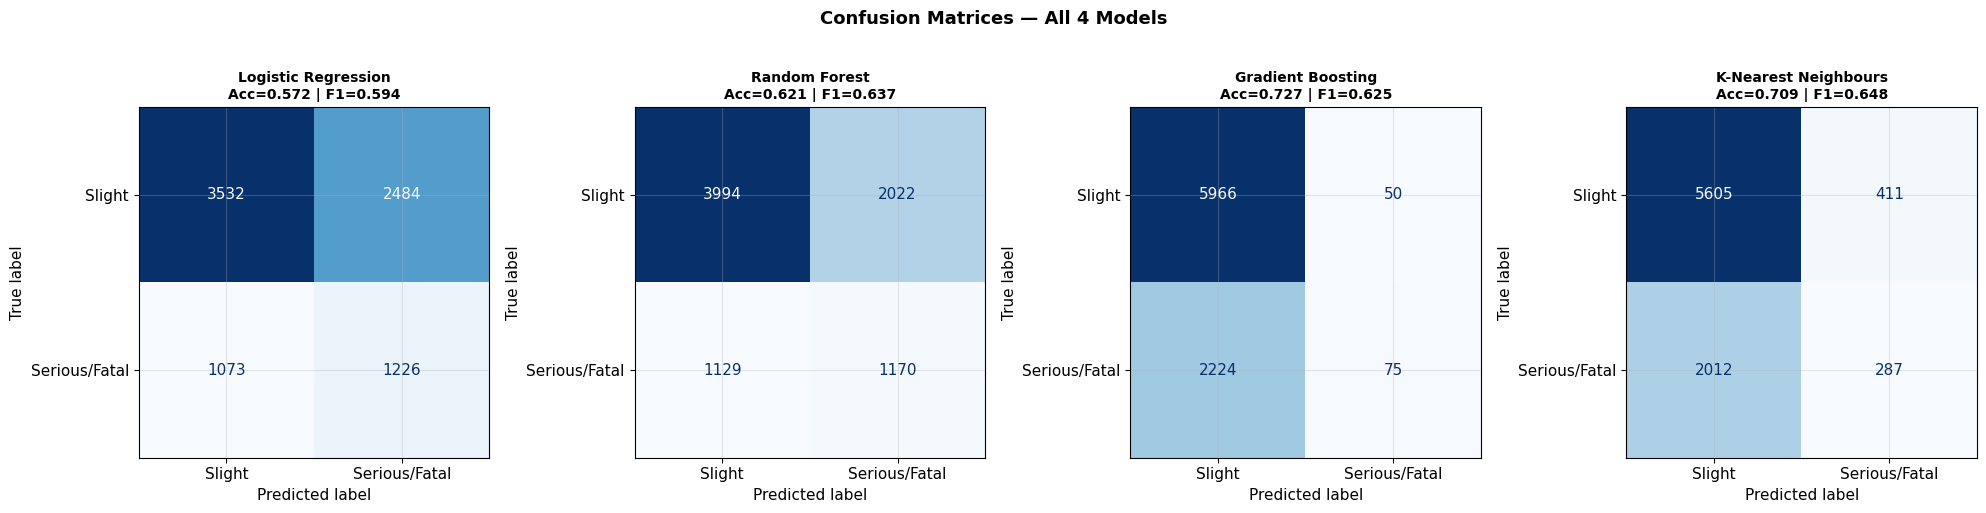

In [35]:
# Figure 16: Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(r['cm'],
                                   display_labels=['Slight','Serious/Fatal'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={r["acc"]:.3f} | F1={r["f1"]:.3f}', fontsize=10)
plt.suptitle('Confusion Matrices — All 4 Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


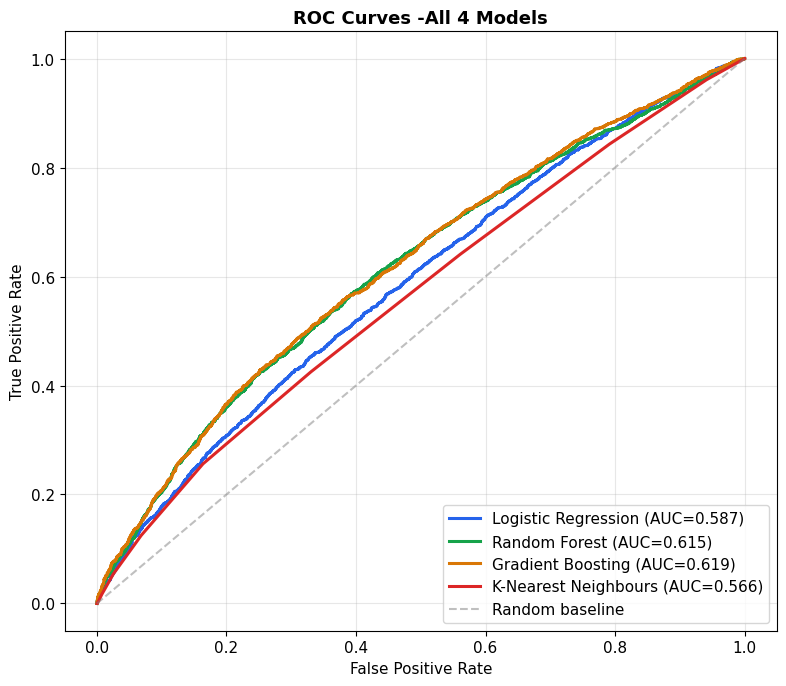

In [36]:
# Figure 17: ROC Curves
fig, ax = plt.subplots(figsize=(8, 7))
clr_roc = ['#2563eb','#16a34a','#d97706','#dc2626']
for (name, r), c in zip(results.items(), clr_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=c, linewidth=2.2,
            label=f"{name} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],'--', color='grey', alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves -All 4 Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [37]:
# Classification reports
for name, r in results.items():
    print(f"Classification Report — {name}")
    print(classification_report(y_test, r['y_pred'],
                                 target_names=['Slight','Serious/Fatal']))


Classification Report — Logistic Regression
               precision    recall  f1-score   support

       Slight       0.77      0.59      0.67      6016
Serious/Fatal       0.33      0.53      0.41      2299

     accuracy                           0.57      8315
    macro avg       0.55      0.56      0.54      8315
 weighted avg       0.65      0.57      0.59      8315

Classification Report — Random Forest
               precision    recall  f1-score   support

       Slight       0.78      0.66      0.72      6016
Serious/Fatal       0.37      0.51      0.43      2299

     accuracy                           0.62      8315
    macro avg       0.57      0.59      0.57      8315
 weighted avg       0.67      0.62      0.64      8315

Classification Report — Gradient Boosting
               precision    recall  f1-score   support

       Slight       0.73      0.99      0.84      6016
Serious/Fatal       0.60      0.03      0.06      2299

     accuracy                           0.7

## 12. Cross-Validation Stability <a id='12'></a>

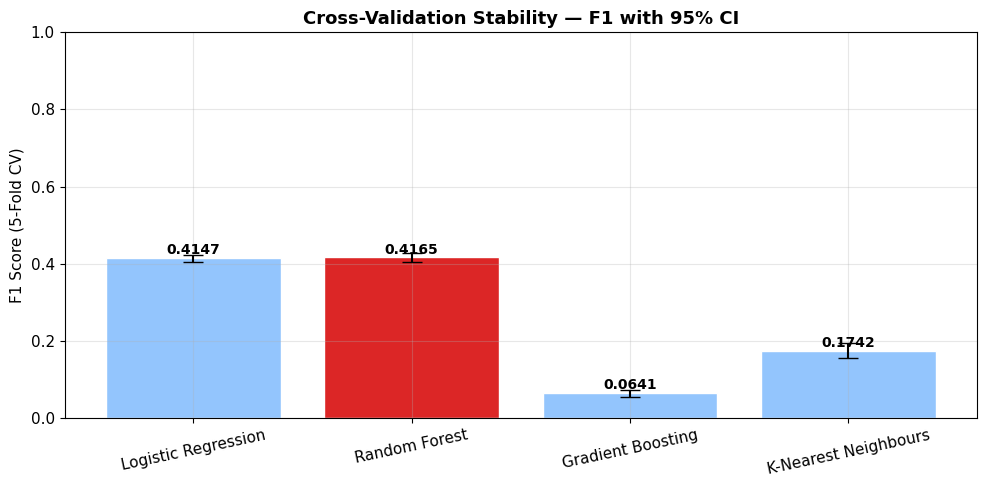


CV Summary:
  Logistic Regression      : CV-F1 = 0.4147 ± 0.0047  (95% CI: [0.4054, 0.4240])
  Random Forest            : CV-F1 = 0.4165 ± 0.0059  (95% CI: [0.4050, 0.4281])
  Gradient Boosting        : CV-F1 = 0.0641 ± 0.0047  (95% CI: [0.0549, 0.0733])
  K-Nearest Neighbours     : CV-F1 = 0.1742 ± 0.0097  (95% CI: [0.1551, 0.1933])


In [38]:
# CV bar chart with 95% CI
fig, ax = plt.subplots(figsize=(10, 5))
cv_means = [results[n]['cv_mean'] for n in results]
cv_stds  = [results[n]['cv_std']  for n in results]
clrs_cv  = ['#dc2626' if n==best_name else '#93c5fd' for n in results]

bars = ax.bar(list(results.keys()), cv_means,
              yerr=[s*1.96 for s in cv_stds],
              color=clrs_cv, capsize=7, edgecolor='white')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score (5-Fold CV)')
ax.set_title('Cross-Validation Stability — F1 with 95% CI')
ax.tick_params(axis='x', rotation=12)
for bar, mean in zip(bars, cv_means):
    ax.text(bar.get_x()+bar.get_width()/2, mean+0.01,
            f'{mean:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCV Summary:")
for name in results:
    r = results[name]
    print(f"  {name:<25}: CV-F1 = {r['cv_mean']:.4f} ± {r['cv_std']:.4f}  "
          f"(95% CI: [{r['cv_mean']-1.96*r['cv_std']:.4f}, "
          f"{r['cv_mean']+1.96*r['cv_std']:.4f}])")


## 13. Feature Importance & Interpretability <a id='13'></a>

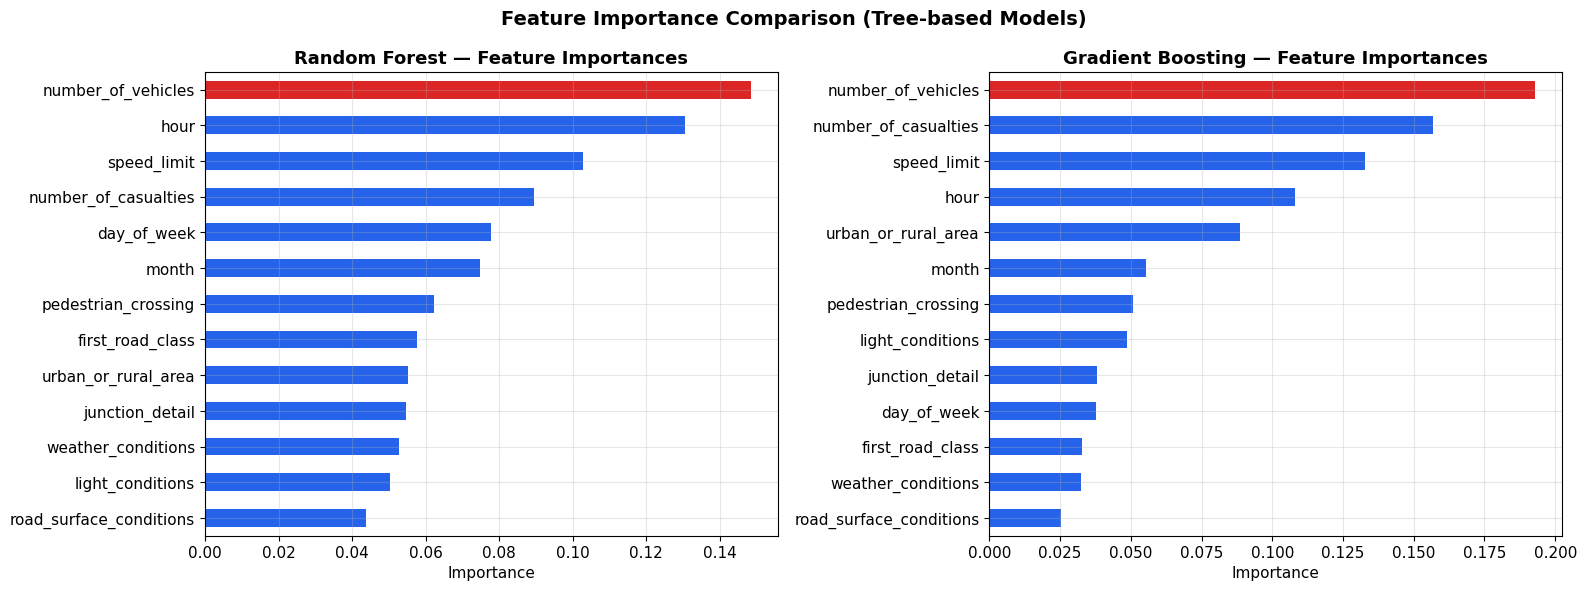

In [39]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, ['Random Forest','Gradient Boosting']):
    model = results[name]['model']
    fi = pd.Series(model.feature_importances_,
                   index=FEAT_COLS).sort_values(ascending=True)
    colors_fi = ['#dc2626' if fi.values[-1]==v else '#2563eb'
                 for v in fi.values]
    fi.plot(kind='barh', ax=ax, color=colors_fi)
    ax.set_title(f'{name} — Feature Importances')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison (Tree-based Models)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


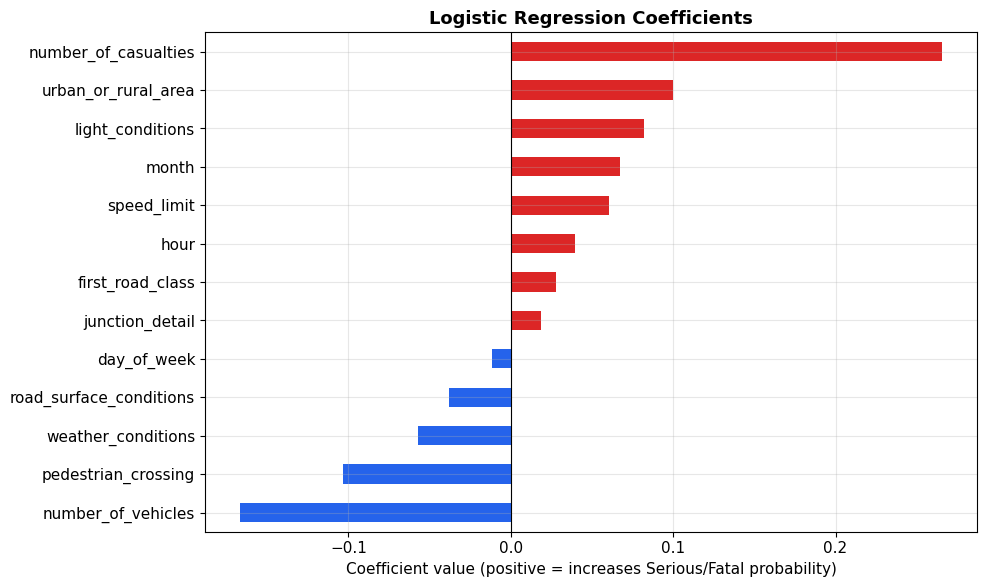

In [40]:
# Logistic Regression coefficients
lr_model = results['Logistic Regression']['model']
coef = pd.Series(lr_model.coef_[0], index=FEAT_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bar_clrs_lr = ['#dc2626' if v>0 else '#2563eb' for v in coef.values]
coef.plot(kind='barh', ax=ax, color=bar_clrs_lr)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient value (positive = increases Serious/Fatal probability)')
ax.set_title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()


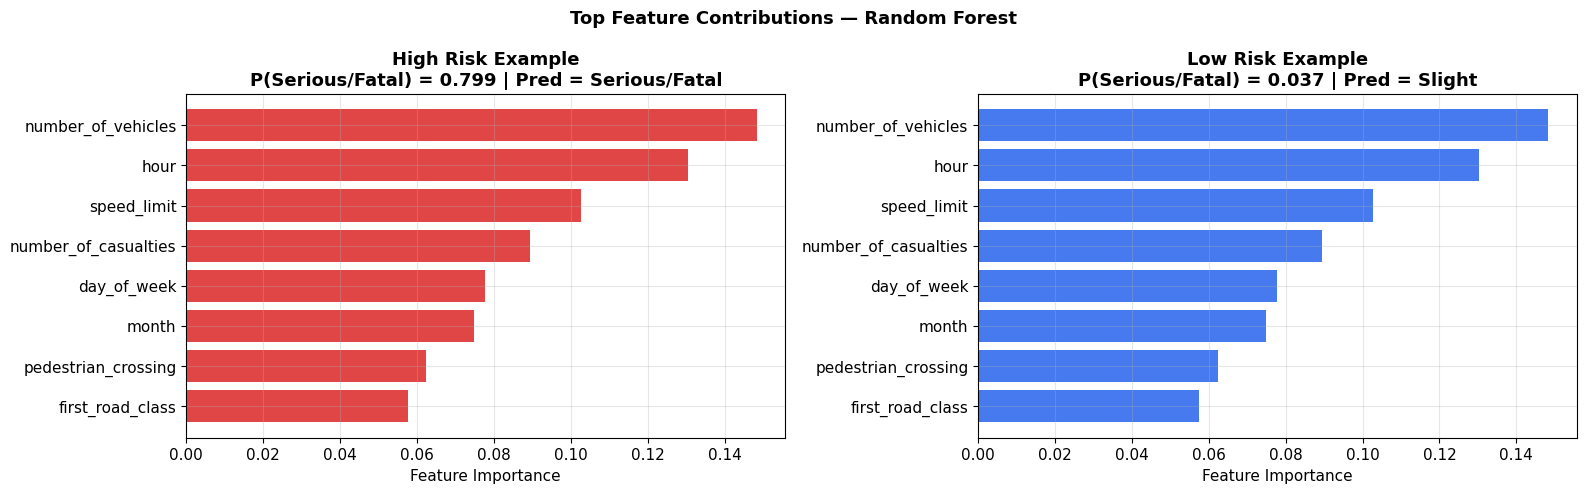

In [41]:
# Sample prediction explanation
best_model_obj = results[best_name]['model']
needs_sc = results[best_name]['needs_scaling']

X_test_arr = X_test_sc if needs_sc else X_test.values
probs_all = best_model_obj.predict_proba(X_test_arr)[:,1]

high_idx = int(np.argmax(probs_all))
low_idx  = int(np.argmin(probs_all))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, idx, title_tag in zip(axes, [high_idx, low_idx],
                               ['High Risk Example','Low Risk Example']):
    prob = probs_all[idx]
    row  = X_test.iloc[idx]

    if hasattr(best_model_obj,'feature_importances_'):
        importance = best_model_obj.feature_importances_
    elif hasattr(best_model_obj,'coef_'):
        importance = np.abs(best_model_obj.coef_[0])
    else:
        importance = np.abs(X_test_arr[idx])
        importance = importance / (importance.sum() + 1e-9)

    top_n = 8
    fi_series = pd.Series(importance, index=FEAT_COLS).sort_values(ascending=False)[:top_n]
    bar_colors_ex = ['#dc2626' if prob > 0.5 else '#2563eb'] * top_n
    ax.barh(fi_series.index[::-1], fi_series.values[::-1],
            color=bar_colors_ex, alpha=0.85)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{title_tag}\nP(Serious/Fatal) = {prob:.3f} | '
                 f'Pred = {"Serious/Fatal" if prob>0.5 else "Slight"}')

plt.suptitle(f'Top Feature Contributions — {best_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [42]:
os.makedirs('artifacts', exist_ok=True)

# Scaler
joblib.dump(scaler, 'artifacts/scaler.pkl')
print("Saved: artifacts/scaler.pkl")

# Classification models
model_filenames = {
    'Logistic Regression':  'artifacts/model_logistic_regression.pkl',
    'Random Forest':        'artifacts/model_random_forest.pkl',
    'Gradient Boosting':    'artifacts/model_gradient_boosting.pkl',
    'K-Nearest Neighbours': 'artifacts/model_k_nearest_neighbours.pkl',
}
for name, fpath in model_filenames.items():
    joblib.dump(results[name]['model'], fpath)
    print(f"Saved: {fpath}")

# Clustering
joblib.dump(kmeans_final, 'artifacts/kmeans_model.pkl')
joblib.dump(pca,          'artifacts/pca_model.pkl')
print("Saved: artifacts/kmeans_model.pkl")
print("Saved: artifacts/pca_model.pkl")


Saved: artifacts/scaler.pkl
Saved: artifacts/model_logistic_regression.pkl
Saved: artifacts/model_random_forest.pkl
Saved: artifacts/model_gradient_boosting.pkl
Saved: artifacts/model_k_nearest_neighbours.pkl
Saved: artifacts/kmeans_model.pkl
Saved: artifacts/pca_model.pkl


In [43]:
# metadata.json
metadata = {
    'feat_cols':    FEAT_COLS,
    'best_model':   best_name,
    'optimal_k':    OPTIMAL_K,
    'class_labels': {'0':'Slight', '1':'Serious/Fatal'},
    'target_def':   'Binary: 1=Serious/Fatal, 0=Slight',
    'train_rows':   int(X_train.shape[0]),
    'test_rows':    int(X_test.shape[0]),
    'class_balance':{str(k):int(v) for k,v in y.value_counts().items()},
    'cluster_sizes':{str(k):int(v) for k,v in
                     ml_df['cluster'].value_counts().sort_index().items()},
    'results': {
        name: {
            'acc':           round(r['acc'],      4),
            'precision':     round(r['precision'],4),
            'recall':        round(r['recall'],   4),
            'f1':            round(r['f1'],       4),
            'f1_macro':      round(r['f1_macro'], 4),
            'auc':           round(r['auc'],      4),
            'cv_mean':       round(r['cv_mean'],  4),
            'cv_std':        round(r['cv_std'],   4),
            'cm':            r['cm'].tolist(),
            'needs_scaling': r['needs_scaling'],
        }
        for name, r in results.items()
    }
}
with open('artifacts/metadata.json','w') as f:
    json.dump(metadata, f, indent=2)
print("Saved: artifacts/metadata.json")

for fname in sorted(os.listdir('artifacts')):
    sz = os.path.getsize(f'artifacts/{fname}')
    print(f"  {fname:<45} {sz/1024:>8.1f} KB")


Saved: artifacts/metadata.json
  kmeans_model.pkl                                 130.9 KB
  metadata.json                                      2.1 KB
  model_gradient_boosting.pkl                      243.8 KB
  model_k_nearest_neighbours.pkl                  7756.6 KB
  model_logistic_regression.pkl                      1.0 KB
  model_random_forest.pkl                        10460.3 KB
  pca_model.pkl                                      1.3 KB
  scaler.pkl                                         1.4 KB
